<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           102 non-null    int64  
 1   CGPA                 102 non-null    float64
 2   Attendance           100 non-null    float64
 3   Study_Hours          100 non-null    float64
 4   Internship           102 non-null    int64  
 5   Projects             102 non-null    int64  
 6   Backlogs             102 non-null    int64  
 7   Communication_Score  102 non-null    int64  
 8   Aptitude_Score       101 non-null    float64
 9   Placed               102 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 8.1 KB
None
        Student_ID        CGPA  Attendance  Study_Hours  Internship  \
count   102.000000  102.000000  100.000000   100.000000  102.000000   
mean   1049.872549    7.515784   77.760000     4.872000    0.254902   
std      29.085967    1.288328   13.76

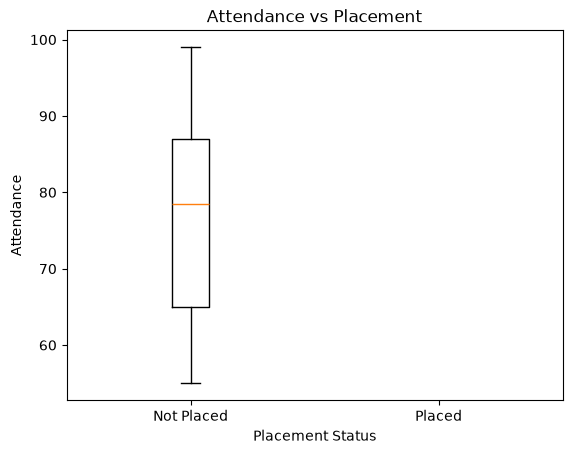

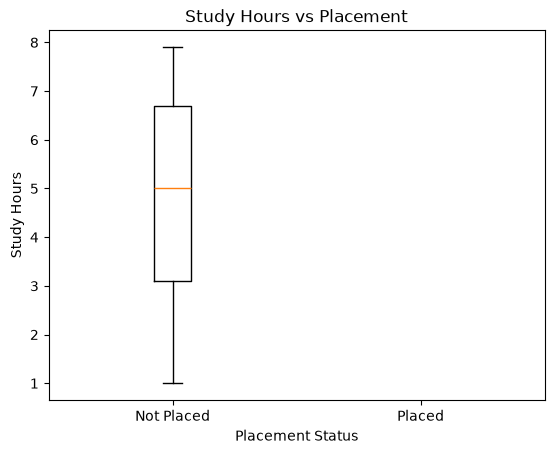

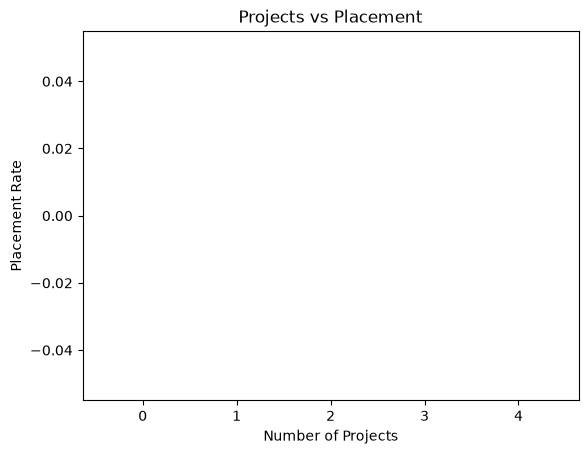

KeyError: -1

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("student_placement_dataset.csv")
print(df.info())
print(df.describe())
print(df.columns)
print(df.head())
print(df.tail())
print(df.isnull().sum())
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].mean())
df["Aptitude_Score"] = df["Aptitude_Score"].fillna(df["Aptitude_Score"].mean())
df = df.drop_duplicates()
print(df.duplicated().sum())
plt.boxplot([
    df[df["Placed"] == 0]["Attendance"],
    df[df["Placed"] == 1]["Attendance"]
])

plt.xticks([1, 2], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Attendance")
plt.title("Attendance vs Placement")

plt.show()
plt.boxplot([
    df[df["Placed"] == 0]["Study_Hours"],
    df[df["Placed"] == 1]["Study_Hours"]
])

plt.xticks([1, 2], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Study Hours")
plt.title("Study Hours vs Placement")

plt.show()
placement_rate = df.groupby("Projects")["Placed"].mean()

plt.bar(placement_rate.index, placement_rate.values)

plt.xlabel("Number of Projects")
plt.ylabel("Placement Rate")
plt.title("Projects vs Placement")

plt.show()


features = [
    "CGPA",
    "Attendance",
    "Study_Hours",
    "Internship",
    "Projects",
    "Backlogs",
    "Communication_Score",
    "Aptitude_Score"
]



x= df.iloc[:,:-1]
y = df.loc[:,-1]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
from sklearn.linear_model import LogisticRegression
lr =  LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score       
report = classification_report(y_test,y_pred)
matrix = confusion_matrix(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)
print(report)
print(matrix)
print(accuracy)
print("\n===== NEW STUDENT =====")

cgpa = float(input("Enter CGPA: "))
attendance = float(input("Enter Attendance: "))
study_hours = float(input("Enter Study Hours: "))
internship = int(input("Internship (0 = No, 1 = Yes): "))
projects = int(input("Enter Number of Projects: "))
backlogs = int(input("Enter Number of Backlogs: "))
communication = int(input("Enter Communication Score (1-10): "))
aptitude = float(input("Enter Aptitude Score: "))

new_student = [[
    cgpa,
    attendance,
    study_hours,
    internship,
    projects,
    backlogs,
    communication,
    aptitude
]]

prediction = lr.predict(new_student)

if prediction[0] == 1:
    print("\nPlacement Prediction: PLACED 🎉")
else:
    print("\nPlacement Prediction: NOT PLACED")